In [1]:
import os
from pathlib import Path
from abc import ABC
from dataclasses import dataclass
from typing import List
from fogvis.db import Database
from contextlib import closing

DB_PATH : Path = Path(os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir, "media", "db")))
db = Database(DB_PATH)

In [2]:
@dataclass
class FogImage:
    image_path: str
    vis_distance: float


@dataclass
class Dataset:
    images: List[FogImage]
    
class Experiment(ABC):
    def __init__(self, db: Database) -> None:
        self.db: Database = db

    def get_datasets(self) -> List[Dataset]:
        """Gathers a list of datasets to be used for training.
        Each item refers to a different set of data to be used in training a
        seperate instance of a model

        Returns:
            list: _description_
        """
        pass

class Linear_vs_Exponential(Experiment):
    def __init__(self, db: Database) -> None:
        super().__init__(db)

    @staticmethod
    def Get_Fog_Images(
        db: Database, fog_type_name: str, scene_name: str
    ) -> list[FogImage]:
        result: list[FogImage] = []
        with closing(db.get_connection().cursor()) as ctx:
            sql: str = """SELECT image.filePath, image.visibilityDistance from image 
            INNER JOIN scene ON image.sceneID = scene.id 
            INNER JOIN camera ON image.cameraID = camera.id
            INNER JOIN environment ON image.environmentID = environment.id
            INNER JOIN fog ON environment.fogID = fog.id
            INNER JOIN fog_type ON fog.typeID = fog_type.id
            WHERE 
                fog_type.name = ? AND
                scene.name = ?
            """
            parms = (fog_type_name, scene_name)
            ctx.execute(sql, parms)
            res = ctx.fetchall()
            if len(res) == 0:
                raise Exception("Failed to get images for scene")

            for r in res:
                path : str = os.path.join(db.import_dir, r[0])
                dist : float = r[1]
                result.append(FogImage(image_path=path, vis_distance=dist))

        return result

    @staticmethod
    def Get_Linear_Dataset(db: Database) -> Dataset:
        return Dataset(
            images=Linear_vs_Exponential.Get_Fog_Images(
                db, "linear", "berthoud_pass_co"
            )
        )

    @staticmethod
    def Get_Exp_Fog_Images(db: Database) -> Dataset:
        return Dataset(
            images=Linear_vs_Exponential.Get_Fog_Images(
                db, "exponential", "berthoud_pass_co"
            )
        )

    def get_datasets(self) -> List[Dataset]:
        result: List[Dataset] = [
            self.Get_Linear_Dataset(self.db),
            self.Get_Exp_Fog_Images(self.db),
        ]
        return result


In [3]:
experiment : Linear_vs_Exponential = Linear_vs_Exponential(db)
datasets = experiment.get_datasets()

## Demo Stuff
This code is just for showing what is in the dataset and making sure paths are correct

### Helpers

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import math
from collections import Counter

def display_image(img : FogImage) -> None: 
    i = mpimg.imread(img.image_path)
    plt.imshow(i)
    plt.axis('off')
    plt.title(f'Distance: {img.vis_distance} meters')
    plt.show()
    

def plot_visibility_classes(dataset):
    """
    Plot a bar graph showing the number of images in each visibility class.

    Each class is the floored number of miles of visibility.
    Example:
        0.3 miles -> class 0
        1.9 miles -> class 1
        5.0 miles -> class 5

    Parameters
    ----------
    dataset : Dataset
        A Dataset object containing a list of FogImage objects.
    """

    METERS_PER_MILE = 1609.344

    visibility_classes = []

    for image in dataset.images:
        try:
            vis_meters = float(image.vis_distance)
        except ValueError:
            print(f"Skipping invalid visibility value: {image.vis_distance}")
            continue

        vis_miles = vis_meters / METERS_PER_MILE
        vis_class = math.floor(vis_miles)

        visibility_classes.append(vis_class)

    class_counts = Counter(visibility_classes)

    if not class_counts:
        print("No valid visibility distances found.")
        return

    # Sort classes by visibility distance
    classes = sorted(class_counts.keys())
    counts = [class_counts[c] for c in classes]

    plt.figure(figsize=(10, 6))
    plt.bar(classes, counts)

    plt.xlabel("Visibility Class, Floored Miles")
    plt.ylabel("Number of Images")
    plt.title("Number of Fog Images by Visibility Distance")

    plt.xticks(classes)
    plt.grid(axis="y", alpha=0.3)

    plt.show()


### Datasets

Linear Images

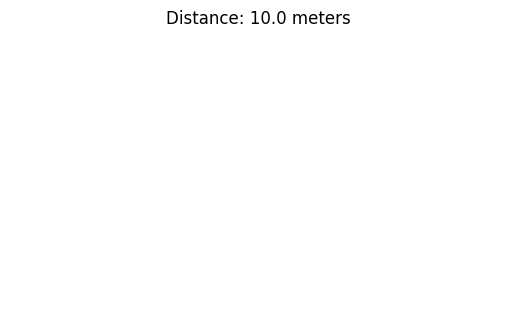

In [5]:
lin = datasets[0]
test_image : FogImage = random.choice(lin.images)
display_image(test_image)

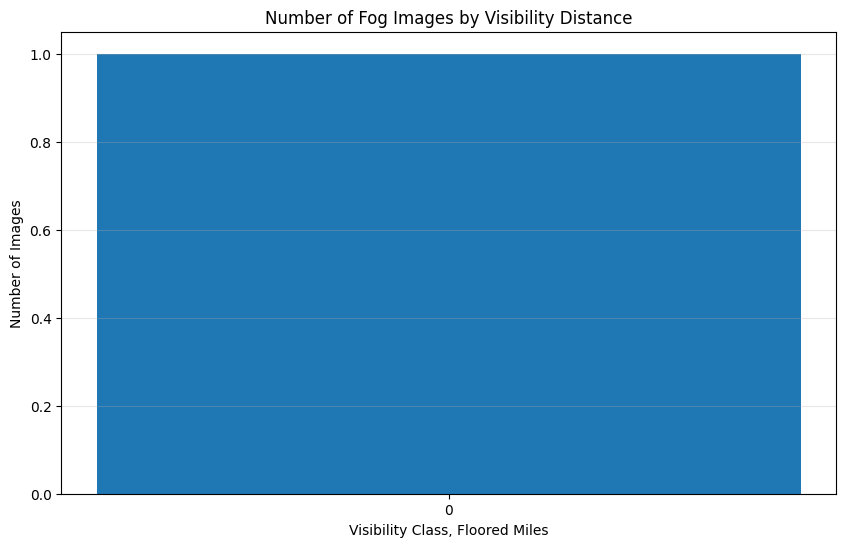

In [6]:
plot_visibility_classes(lin)

Exponential Images

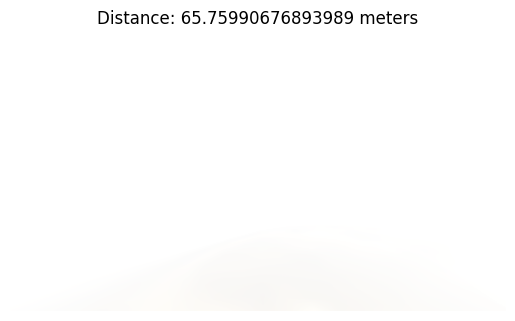

In [7]:
exp = datasets[1]
test_image : FogImage = random.choice(exp.images)
display_image(test_image)

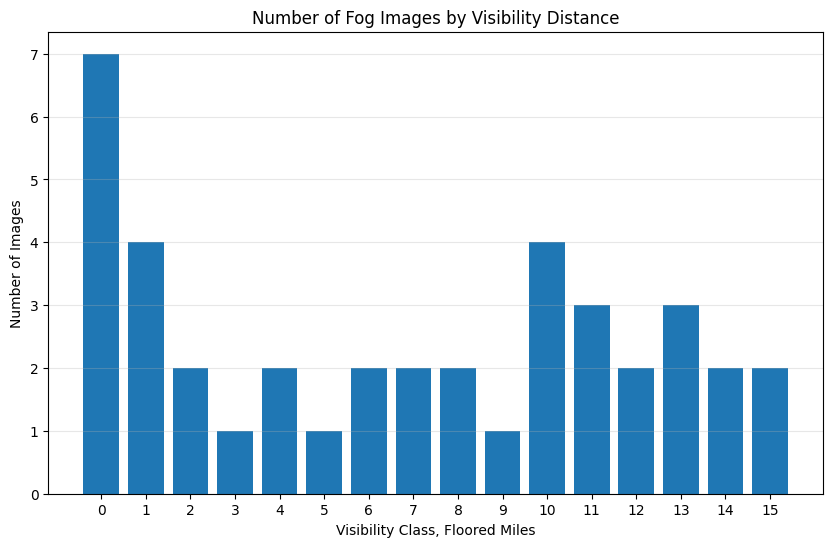

In [8]:
plot_visibility_classes(exp)